In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 70
WINDOW_STRIDE_SAMPLES = 10
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [3]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN rtParent.title like '% Tap' and smt.group_id is not null THEN rtParent.title ELSE 'No Gesture' END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title like '% Tap' and smt.group_id is not null THEN 1 ELSE 0 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [4]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [5]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [6]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [7]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        269628
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64

In [8]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [9]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    36375
6331fbd1-76bb-48d6-92a2-80a55a70d134    31589
696b4743-9d39-4fb1-8271-90e7d48652af    21096
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    43728
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    33659
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    39524
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    35425
fdd02af8-c764-43ba-8247-c612f85568b4    41799
dtype: int64

In [10]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel',
 'group_id']

In [11]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

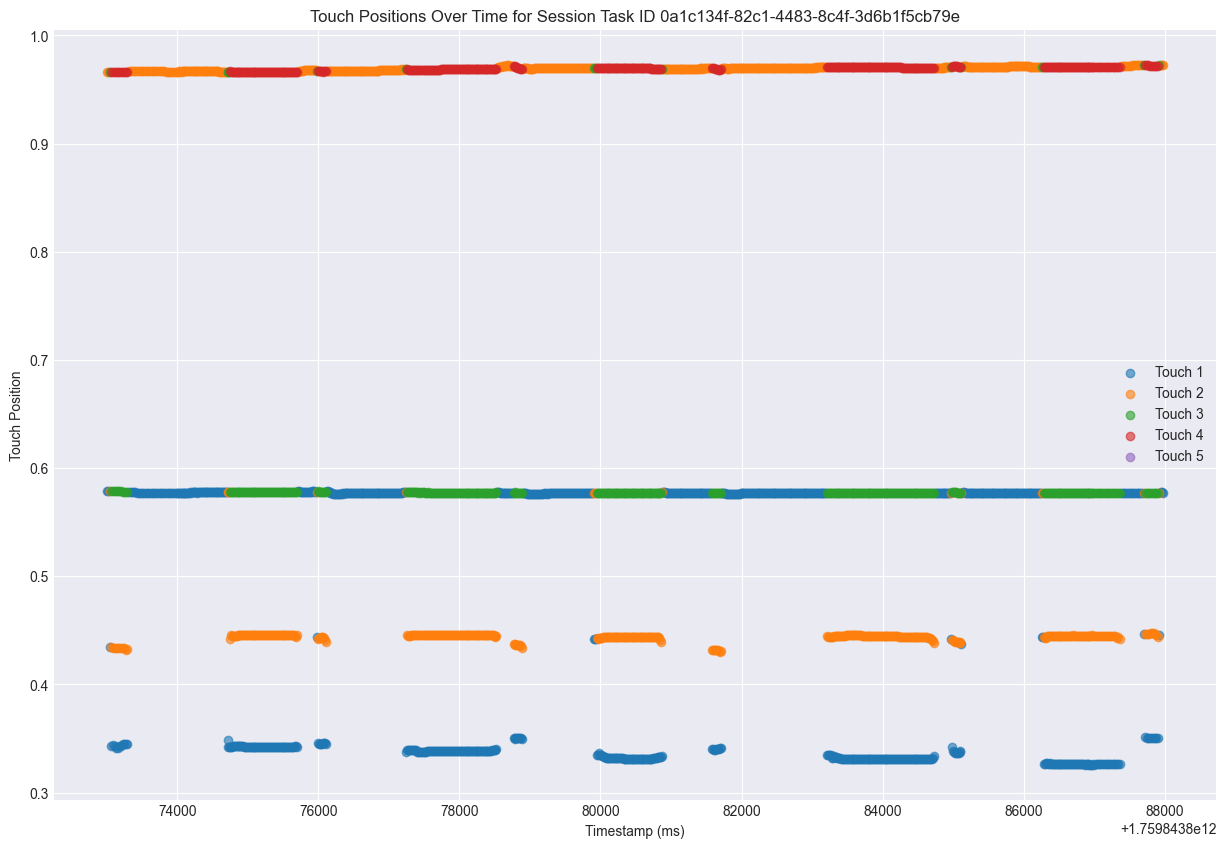

In [12]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [13]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


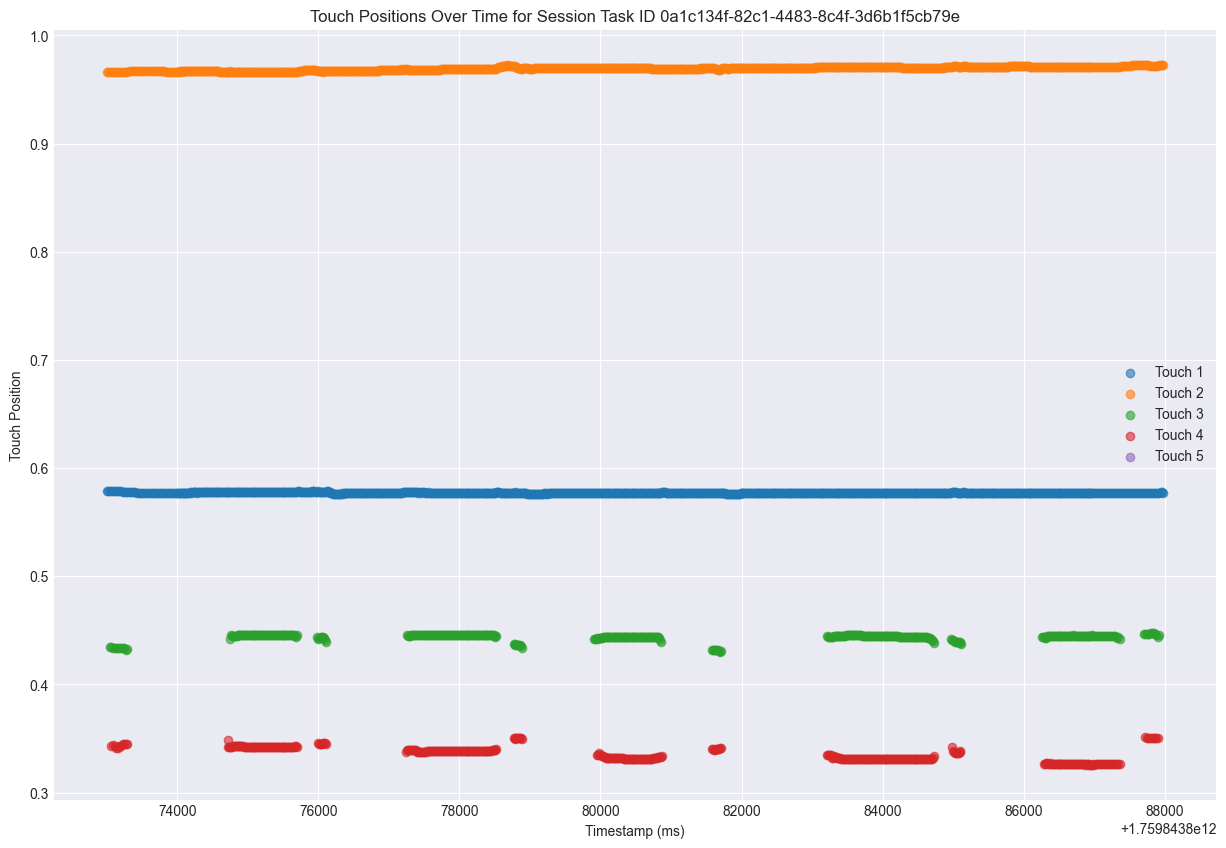

In [14]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [15]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position         0
touch_1_pressure         0
touch_1_channel          0
touch_2_position         0
touch_2_pressure         0
touch_2_channel          0
touch_3_position         0
touch_3_pressure         0
touch_3_channel          0
touch_4_position         0
touch_4_pressure         0
touch_4_channel          0
touch_5_position         0
touch_5_pressure         0
touch_5_channel          0
group_id            204519
dtype: int64

In [16]:
# Print the LABEL_COLUMN counts
print(df_clean[LABEL_COLUMN].value_counts())

parent_gesture
No Gesture                        269628
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64


In [17]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=10):
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    # Instant Features
    pressure_cols = [f"touch_{i+1}_pressure" for i in range(5)]
    add_feature("num_active_touches_instant", (feature_df[pressure_cols] > 0).sum(axis=1))
    # Distances for each finger in the rolling window to each other finger
    for (i, j) in combinations(range(1, 6), 2):
        pos_i = feature_df[f'touch_{i}_position']
        pos_j = feature_df[f'touch_{j}_position']
        p_i = feature_df[f"touch_{i}_pressure"]
        p_j = feature_df[f"touch_{j}_pressure"]

        # distance only when both fingers are active; else 0 (or np.nan if you prefer)
        dist_col = f"dist_{i}_{j}"
        dist = short_dist(pos_i, pos_j)
        both_active = (p_i > 0) & (p_j > 0)
        add_feature(dist_col, np.where(both_active, dist, 0.0))
    
    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        add_feature(f'touch_{touch_num}_is_active', (feature_df[pressure_col] > 0).astype(int))
        
        add_feature(f'{position_col}_smoothed', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_smoothed', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{channel_col}_smoothed', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))

    add_feature("num_active_touches_mean", feature_df["num_active_touches_instant"]
            .rolling(window=smoothing_window, min_periods=1)
            .mean())
    add_feature("num_active_touches_max", feature_df["num_active_touches_instant"]
            .rolling(window=smoothing_window, min_periods=1)
            .max())
    
    dist_cols = [c for c in feature_df.columns if c.startswith("dist_")]
    for col in dist_cols:
        add_feature(f"{col}_rollmean", feature_df[col]
            .rolling(window=smoothing_window, min_periods=1)
            .mean())
        add_feature(f"{col}_rollstd", feature_df[col]
            .rolling(window=smoothing_window, min_periods=1)
            .std()
            .fillna(0.0))

    return feature_df, additional_features

In [18]:
df, additional_columns = create_feature_df(df_clean)
feature_columns = SENSOR_COLUMNS + additional_columns

df = df.sort_values(
    by=["participant_id", "session_task_id", TIMESTAMP_COLUMN]
).reset_index(drop=True)

gesture_block = 0
prev_pid = None
prev_sid = None
prev_is_gesture = None
prev_label = None
prev_group_id = None
blocks = []

for i, row in df.iterrows():
    pid = row["participant_id"]
    sid = row["session_task_id"]
    is_g = row["is_gesture"]
    lab = row[LABEL_COLUMN]
    group_id = row["group_id"]

    # New block when:
    # - participant or session changes
    # - or gesture/background state changes
    # - or gesture label changes
    if (
        pid != prev_pid or
        sid != prev_sid or
        is_g != prev_is_gesture or
        lab != prev_label or
        group_id != prev_group_id
    ):
        gesture_block += 1

    blocks.append(gesture_block)

    prev_pid = pid
    prev_sid = sid
    prev_is_gesture = is_g
    prev_label = lab
    prev_group_id = group_id

df["gesture_block"] = blocks

In [19]:
df.head()

,id,session_task_id,session_task_row_index,timestamp,timestamp_ms,button_pressed,motor_angle,gesture,parent_gesture,participant_id,is_gesture,group_id,estimated_timestamp,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,active_ids,num_active_touches_instant,dist_1_2,dist_1_3,dist_1_4,dist_1_5,dist_2_3,dist_2_4,dist_2_5,dist_3_4,dist_3_5,dist_4_5,touch_1_is_active,touch_1_position_smoothed,touch_1_pressure_smoothed,touch_1_channel_smoothed,touch_1_position_diff,touch_1_pressure_diff,touch_1_channel_diff,touch_1_position_rollstd,touch_1_pressure_rollstd,touch_1_channel_rollstd,touch_2_is_active,touch_2_position_smoothed,touch_2_pressure_smoothed,touch_2_channel_smoothed,touch_2_position_diff,touch_2_pressure_diff,touch_2_channel_diff,touch_2_position_rollstd,touch_2_pressure_rollstd,touch_2_channel_rollstd,touch_3_is_active,touch_3_position_smoothed,touch_3_pressure_smoothed,touch_3_channel_smoothed,touch_3_position_diff,touch_3_pressure_diff,touch_3_channel_diff,touch_3_position_rollstd,touch_3_pressure_rollstd,touch_3_channel_rollstd,touch_4_is_active,touch_4_position_smoothed,touch_4_pressure_smoothed,touch_4_channel_smoothed,touch_4_position_diff,touch_4_pressure_diff,touch_4_channel_diff,touch_4_position_rollstd,touch_4_pressure_rollstd,touch_4_channel_rollstd,touch_5_is_active,touch_5_position_smoothed,touch_5_pressure_smoothed,touch_5_channel_smoothed,touch_5_position_diff,touch_5_pressure_diff,touch_5_channel_diff,touch_5_position_rollstd,touch_5_pressure_rollstd,touch_5_channel_rollstd,num_active_touches_mean,num_active_touches_max,dist_1_2_rollmean,dist_1_2_rollstd,dist_1_3_rollmean,dist_1_3_rollstd,dist_1_4_rollmean,dist_1_4_rollstd,dist_1_5_rollmean,dist_1_5_rollstd,dist_2_3_rollmean,dist_2_3_rollstd,dist_2_4_rollmean,dist_2_4_rollstd,dist_2_5_rollmean,dist_2_5_rollstd,dist_3_4_rollmean,dist_3_4_rollstd,dist_3_5_rollmean,dist_3_5_rollstd,dist_4_5_rollmean,dist_4_5_rollstd,gesture_block
0,7ae236df-3b8a-46fe-be4b-fcabf2850ad1,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,639,2025-10-07 13:31:13,1759843873000,0,0.997409,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,03f74f16-3fea-4c43-9979-64c4636df12a,2025-10-07 13:31:13.000000000,0.578513,0.377551,0.400000,0.966209,0.572171,0.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,"[0, 1]",2,0.387696,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,1,0.578513,0.377551,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,0.966209,0.572171,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,2.0,0.387696,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,1
1,139f6348-aacb-4142-b68b-768cbbb6f919,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,640,2025-10-07 13:31:13,1759843873022,0,0.997431,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,03f74f16-3fea-4c43-9979-64c4636df12a,2025-10-07 13:31:13.022727273,0.578533,0.375364,0.400000,0.966277,0.580334,0.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,"[0, 1]",2,0.387745,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,1,0.578523,0.376458,0.400000,0.000020,-0.002187,0.000000,0.000014,0.001546,0.000000,1,0.966243,0.576252,0.500000,0.000069,0.008163,0.000000,0.000049,0.005772,0.000000,0,0.000000,0.000000,0.000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,2.0,0.387720,0.000035,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000

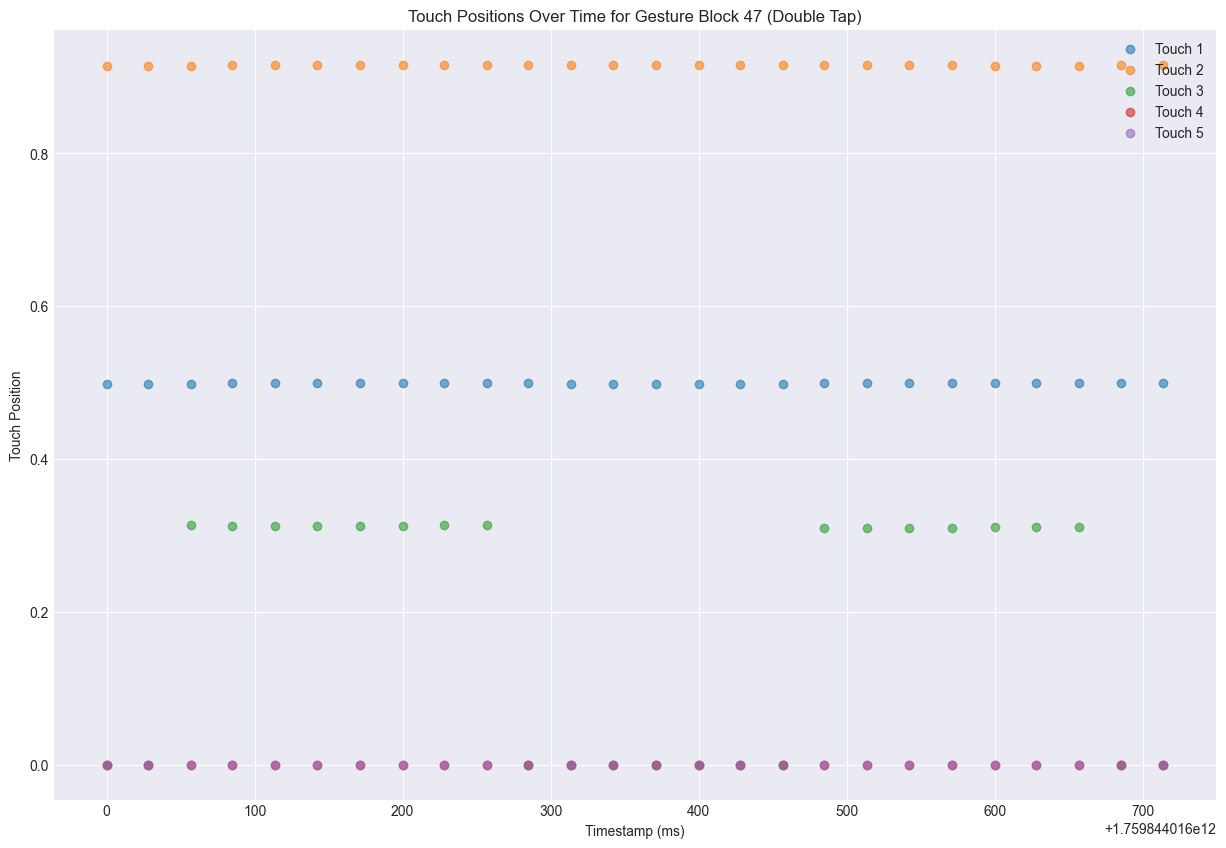

In [20]:
# draw a graph of the finger positions for the first gesture_block and title it with the parent_gesture

# get the index of the unique gesture block that is a "Tap and Hold" gesture
idx_tap_and_hold = np.where(df["gesture_block"].unique() == df[df[LABEL_COLUMN] == "Double Tap"]["gesture_block"].iloc[1])[0][0]

plt.figure(figsize=(15, 10))
first_gesture_block = df["gesture_block"].unique()[idx_tap_and_hold]
gesture_block_df = df[df["gesture_block"] == first_gesture_block]
for touch_num in range(1, 6):
    plt.scatter(
        gesture_block_df["timestamp_ms"], 
        gesture_block_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Gesture Block {first_gesture_block} ({gesture_block_df[LABEL_COLUMN].iloc[0]})")
plt.legend()
plt.show()

In [21]:
# Print unique "gesture" column counts
print(df["gesture"].value_counts())

gesture
Tap and Hold (3 Finger)                      22873
Pinch Swipe (Rechts)                         14960
Tap and Hold (2 Finger)                      14352
Two-Finger Tap (3 Finger)                    13072
Lay On (2 Fingers)                           12997
Two-Finger Double Tap (4 Finger)             12911
Pinch Swipe (Links)                          12417
Knob Turn (3 Fingers)                        12172
Knob Turn (All Fingers)                      11944
Lay On (3 Fingers)                           11869
Double Tap (4 Finger)                        10872
Spread Swipe (Rechts)                        10249
Two-Finger Double Tap (3 Finger)             10028
Two-Finger Opposite Double Tap (4 Finger)     9715
Single Swipe (All Air)                        9707
Spread Swipe (Links)                          9332
Two-Finger Opposite Tap (4 Finger)            9185
Single Swipe (3 Finger)                       9109
Two-Finger Tap (4 Finger)                     8999
Two-Finger Opposite Tap

In [22]:
gesture_blocks = (
    df[df["is_gesture"] == 1]
    # df
    .groupby(["participant_id", "session_task_id", "group_id", "gesture_block"])
)
print(f"Total gesture blocks (excluding 'No Gesture'): {len(gesture_blocks)}")

Total gesture blocks (excluding 'No Gesture'): 606


In [23]:
sequences = []   # list of arrays, each (T_i, D)
labels = []      # list of strings or ints
meta = []

for (pid, sid, group_id, gb), gdf in gesture_blocks:
    # Extract feature matrix for this gesture
    X_seq = gdf[feature_columns].to_numpy(dtype="float32")  # shape (T_i, D)
    if len(X_seq) == 0:
        continue

    sequences.append(X_seq)
    labels.append(gdf[LABEL_COLUMN].iloc[0])  # all rows in block share the same label
    meta.append({
        "group_id": group_id,
        "participant_id": pid,
        "session_task_id": sid,
        "gesture_block": gb,
        "num_samples": len(X_seq),
    })

In [24]:
# Print the number of sequences and unique labels
print(f"Extracted {len(sequences)} sequences with {len(set(labels))} unique labels.")
# Print the unique labels and their counts
label_counts = pd.Series(labels).value_counts()
print("Label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Extracted 606 sequences with 6 unique labels.
Label counts:
  Two-Finger Tap: 109
  Two-Finger Opposite Tap: 101
  Double Tap: 101
  Single Tap: 100
  Two-Finger Opposite Double Tap: 98
  Two-Finger Double Tap: 97


'No Gesture' sequences length: min=0, max=0
Gesture sequences length: min=8, max=55
Labels with sequence length greater than 500: set()
Longest sequence session_task_id: b060f668-08fc-4e5a-97f0-ed47f34acdd4, gesture_block: 1667, length: 55, label: Two-Finger Double Tap, group_id: 383b1bee-e378-475b-8c8d-3ced18587627


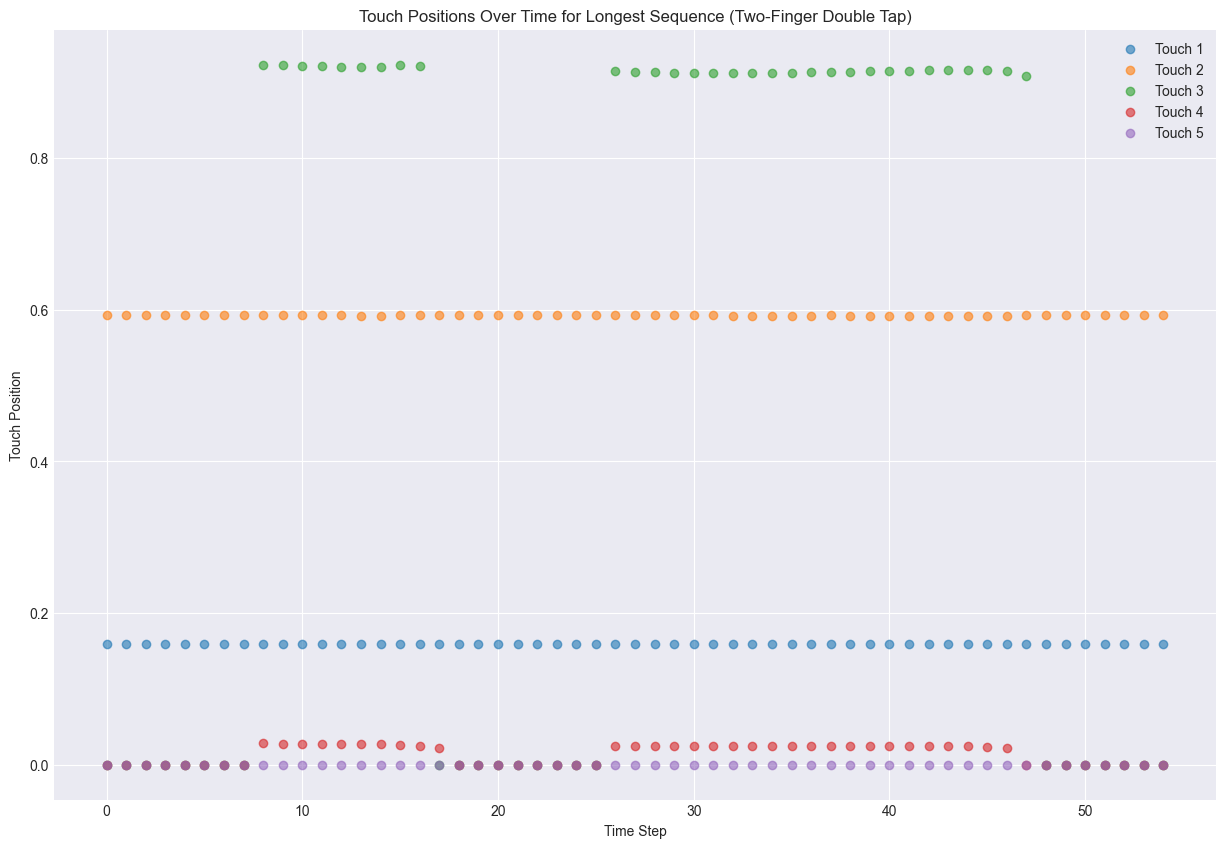

In [25]:
# Show the amount of "No Gesture" sequences, that sequence length is smaller or equal to the max length of the other gestures
no_gesture_lengths = [seq.shape[0] for seq, lab in zip(sequences, labels) if lab == "No Gesture"]
min_gesture_lengths = min(no_gesture_lengths) if no_gesture_lengths else 0
max_gesture_lengths = max(no_gesture_lengths) if no_gesture_lengths else 0
print(f"'No Gesture' sequences length: min={min_gesture_lengths}, max={max_gesture_lengths}")

gesture_lengths = [seq.shape[0] for seq, lab in zip(sequences, labels) if lab != "No Gesture"]
min_gesture_lengths = min(gesture_lengths) if gesture_lengths else 0
max_gesture_lengths = max(gesture_lengths) if gesture_lengths else 0
print(f"Gesture sequences length: min={min_gesture_lengths}, max={max_gesture_lengths}")

# Print all labels where the sequence length is greater than 500
long_gesture_labels = [lab for seq, lab in zip(sequences, labels) if seq.shape[0] > 500]
print(f"Labels with sequence length greater than 500: {set(long_gesture_labels)}")

# Draw a graph of all finger positions for the longest sequence that is not a "No Gesture"
max_length = 0
longest_seq = None
for seq, lab, met in zip(sequences, labels, meta):
    if lab != "No Gesture" and seq.shape[0] > max_length:
        max_length = seq.shape[0]
        longest_seq = (seq, lab, met)
if longest_seq:
    seq, lab, met = longest_seq

    # Print the session_task_id
    print(f"Longest sequence session_task_id: {met['session_task_id']}, gesture_block: {met['gesture_block']}, length: {seq.shape[0]}, label: {lab}, group_id: {met['group_id']}")

    plt.figure(figsize=(15, 10))
    time_axis = np.arange(seq.shape[0])
    for touch_num in range(1, 6):
        plt.scatter(
            time_axis, 
            seq[:, feature_columns.index(f"touch_{touch_num}_position")], 
            label=f"Touch {touch_num}", 
            alpha=0.6
        )
    plt.xlabel("Time Step")
    plt.ylabel("Touch Position")
    plt.title(f"Touch Positions Over Time for Longest Sequence ({lab})")
    plt.legend()
    plt.show()

In [26]:
# Count the number of sequences with No Gesture, that are longer than the max length of the other gestures
no_gesture_long_sequences = [
    (seq, lab) for seq, lab in zip(sequences, labels) 
    if lab == "No Gesture" and seq.shape[0] > max(gesture_lengths)
]
print(f"Number of 'No Gesture' sequences longer than max gesture length: {len(no_gesture_long_sequences)} leaving out {len(no_gesture_lengths) - len(no_gesture_long_sequences)} sequences.")

Number of 'No Gesture' sequences longer than max gesture length: 0 leaving out 0 sequences.


In [27]:
# Filter to only include sequences that are equal to or shorter than the max length of the other gestures
filtered_sequences = []
filtered_labels = []
filtered_meta = []
for seq, lab, meta in zip(sequences, labels, meta):
    if lab == "No Gesture" and seq.shape[0] > max(gesture_lengths):
        continue
    filtered_sequences.append(seq)
    filtered_labels.append(lab)
    filtered_meta.append(meta)
sequences = filtered_sequences
labels = filtered_labels
meta = filtered_meta

In [28]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(labels)           # shape (N,)
num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes)     # shape (N, num_classes)


In [29]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(seq.shape[0] for seq in sequences)  # e.g. 400
D = sequences[0].shape[1]

X_padded = pad_sequences(
    sequences,
    maxlen=max_len,
    dtype="float32",
    padding="post",
    truncating="post",
    value=0.0      # padding value
)  # shape: (N, max_len, D)
X = X_padded

print(X.shape)


(606, 55, 100)


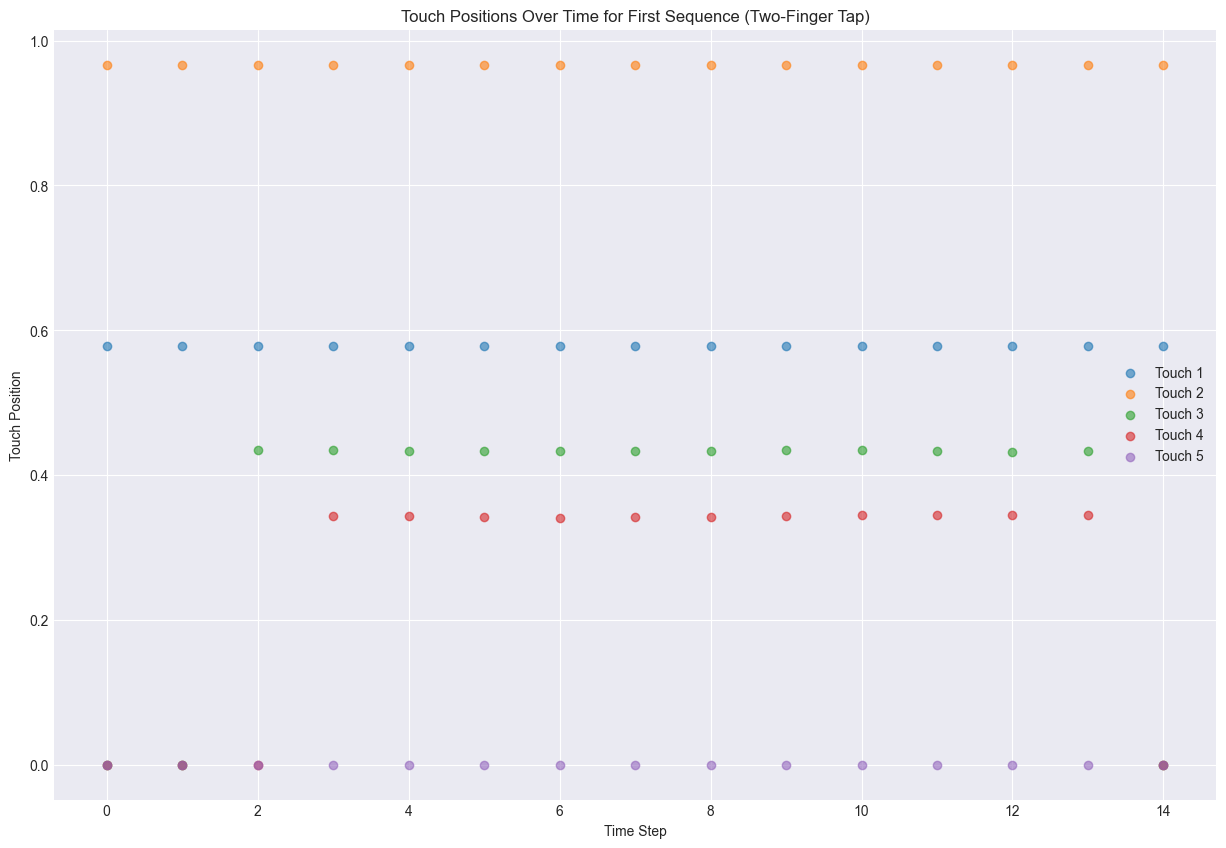

In [30]:
# Draw a graph of the finger positions of the first entry in sequences
plt.figure(figsize=(15, 10))
first_sequence = sequences[0]
for touch_num in range(1, 6):
    plt.scatter(
        range(first_sequence.shape[0]), 
        first_sequence[:, feature_columns.index(f"touch_{touch_num}_position")], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Time Step")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for First Sequence ({labels[0]})")
plt.legend()
plt.show()

In [31]:
unique_participants = df['participant_id'].unique()
print(f"Unique participants: {unique_participants}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733'
 '6331fbd1-76bb-48d6-92a2-80a55a70d134'
 '696b4743-9d39-4fb1-8271-90e7d48652af'
 '6a1b56e6-47ce-43cb-96cb-713d055d8f6d'
 '707c3867-fe15-4b05-bf7b-fc5f3b501fb1'
 '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0'
 'd3b39f0f-b799-4d69-b7a3-a663e5c7438f'
 'fdd02af8-c764-43ba-8247-c612f85568b4']
Train participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733', '696b4743-9d39-4fb1-8271-90e7d48652af', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d', '707c3867-fe15-4b05-bf7b-fc5f3b501fb1', '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0', 'fdd02af8-c764-43ba-8247-c612f85568b4']
Validation participants: ['6331fbd1-76bb-48d6-92a2-80a55a70d134']
Test participants: ['d3b39f0f-b799-4d69-b7a3-a663e5c7438f']


In [32]:
# Split participants into train, val, test sets
train_indices = [i for i, met in enumerate(meta) if met['participant_id'] in train_participants]
val_indices = [i for i, met in enumerate(meta) if met['participant_id'] in val_participants]
test_indices = [i for i, met in enumerate(meta) if met['participant_id'] in test_participants]
X_train, y_train = X[train_indices], y[train_indices]
X_val, y_val = X[val_indices], y[val_indices]
X_test, y_test = X[test_indices], y[test_indices]
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (450, 55, 100), (450, 6)
Validation set: (81, 55, 100), (81, 6)
Test set: (75, 55, 100), (75, 6)


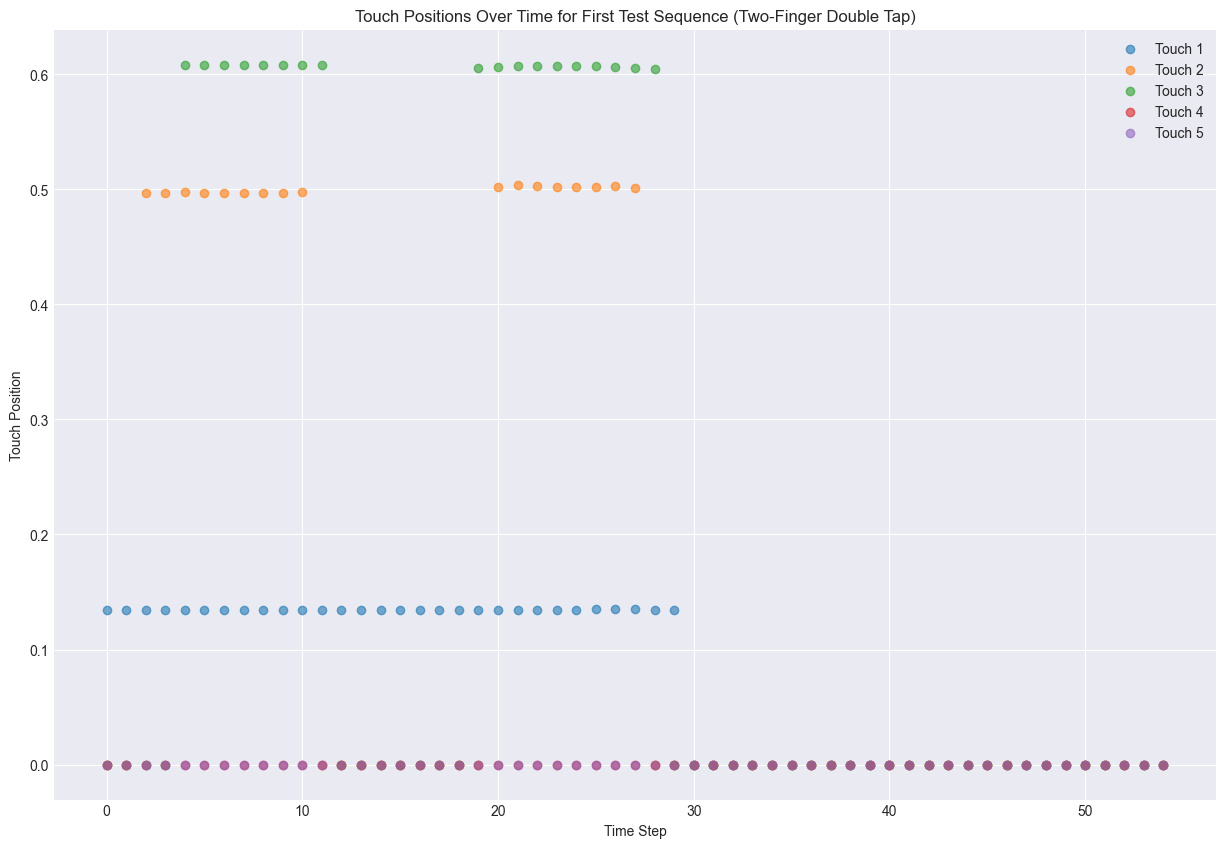

In [33]:
# Draw a graph of the first test sequence window with the correct label in the title
plt.figure(figsize=(15, 10))
first_test_sequence = X_test[0]
for touch_num in range(1, 6):
    plt.scatter(
        range(first_test_sequence.shape[0]), 
        first_test_sequence[:, feature_columns.index(f"touch_{touch_num}_position")], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Time Step")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for First Test Sequence ({le.inverse_transform([np.argmax(y_test[0])])[0]})")
plt.legend()
plt.show()

In [34]:
# Per label, print the amount of samples in each split in one row
train_counts = pd.Series(np.argmax(y_train, axis=1)).value_counts().sort_index()
val_counts = pd.Series(np.argmax(y_val, axis=1)).value_counts().sort_index()
test_counts = pd.Series(np.argmax(y_test, axis=1)).value_counts().sort_index()
print("Label counts per split:")
for label_idx in range(num_classes):
    train_count = train_counts.get(label_idx, 0)
    val_count = val_counts.get(label_idx, 0)
    test_count = test_counts.get(label_idx, 0)
    label_name = le.classes_[label_idx]
    print(f"  {label_name}: Train={train_count}, Val={val_count}, Test={test_count}")

Label counts per split:
  Double Tap: Train=76, Val=12, Test=13
  Single Tap: Train=76, Val=12, Test=12
  Two-Finger Double Tap: Train=70, Val=15, Test=12
  Two-Finger Opposite Double Tap: Train=72, Val=14, Test=12
  Two-Finger Opposite Tap: Train=75, Val=12, Test=14
  Two-Finger Tap: Train=81, Val=16, Test=12


In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam

max_len = X_train.shape[1]
D = X_train.shape[2]
num_classes = y_train.shape[1]

# Create the model as CNN + LSTM
model = Sequential()
model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))
model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 55, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 51, 64)         │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,526 (545.02 KB)

 Trainable params: 139,526 (545.02 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
print(max_len)

55


In [37]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

batch_size = 16     # optimization knob: [16, 32, 64]
epochs = 100        # upper limit; early stopping will cut it earlier

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2489 - loss: 1.6579 - val_accuracy: 0.3333 - val_loss: 1.4591
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3311 - loss: 1.3511 - val_accuracy: 0.2346 - val_loss: 1.5929
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4044 - loss: 1.2152 - val_accuracy: 0.5062 - val_loss: 1.1157
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6000 - loss: 0.9247 - val_accuracy: 0.4568 - val_loss: 1.4730
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6622 - loss: 0.8019 - val_accuracy: 0.6420 - val_loss: 0.7967
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8089 - loss: 0.5693 - val_accuracy: 0.5802 - val_loss: 1.5091
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8356 - loss: 0.4832 - val_accuracy: 0.7160 - val_loss: 0.7896
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8489 - loss: 0.3966 - val_accuracy: 0.8025 - 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


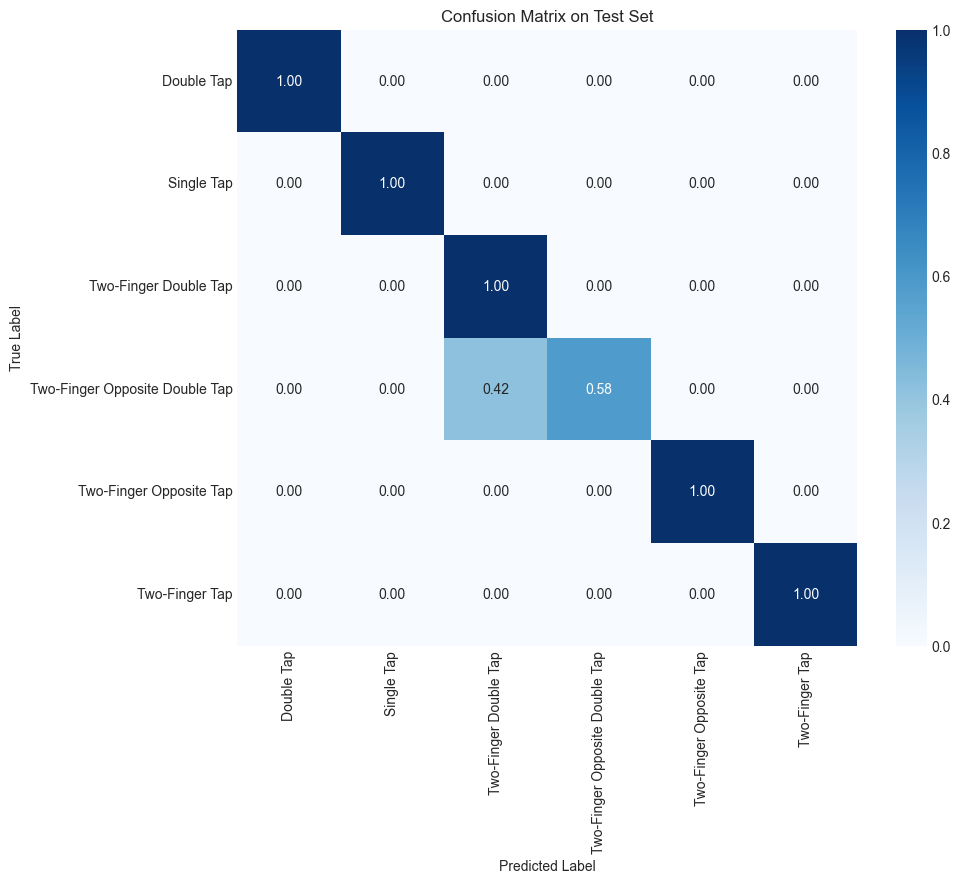

In [38]:
# Draw heatmap of confusion matrix for test set
from sklearn.metrics import confusion_matrix

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

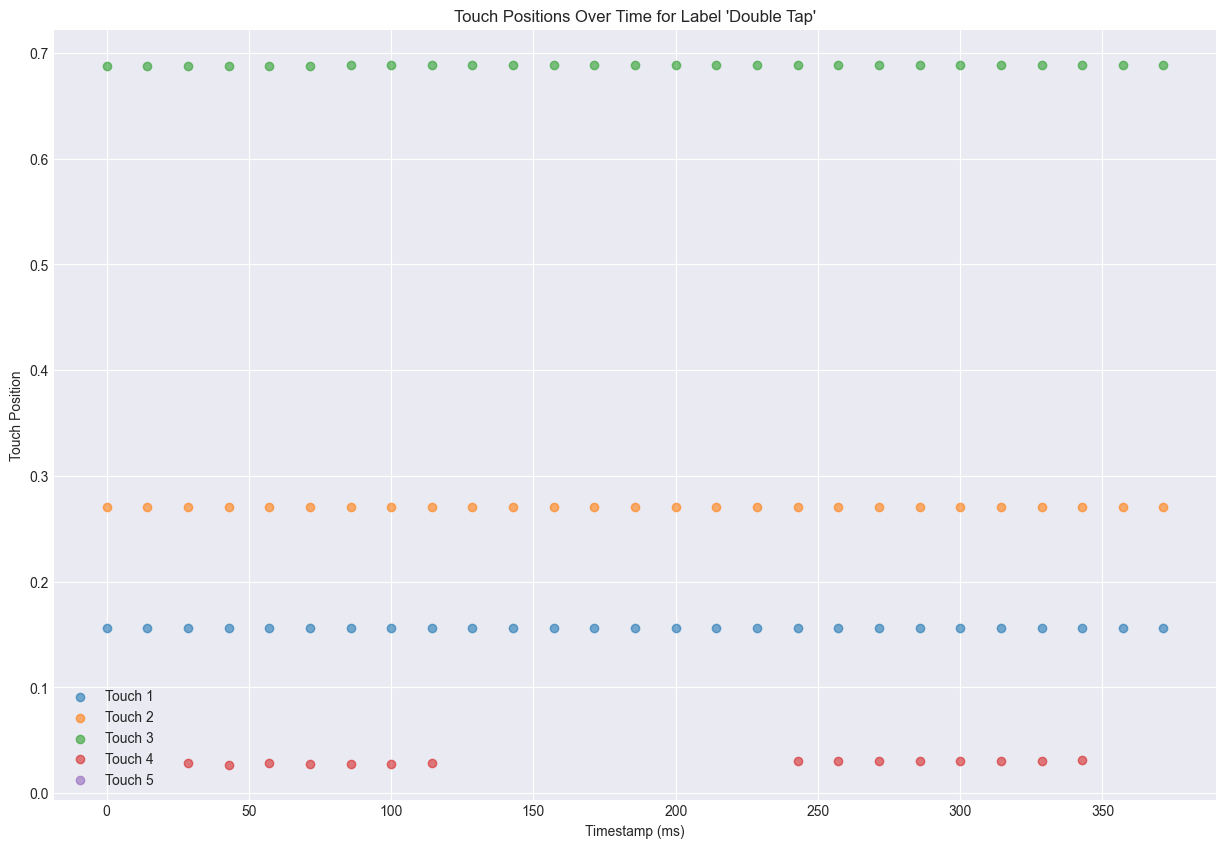

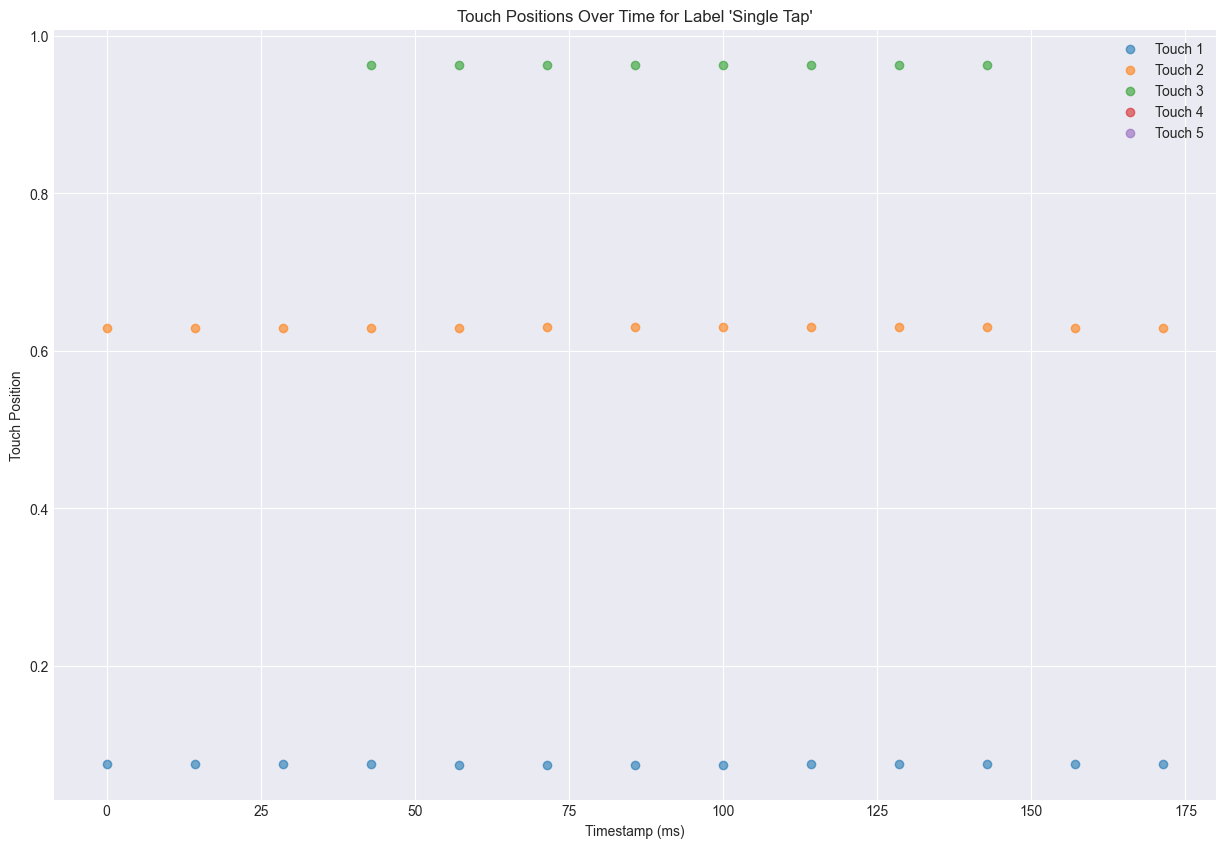

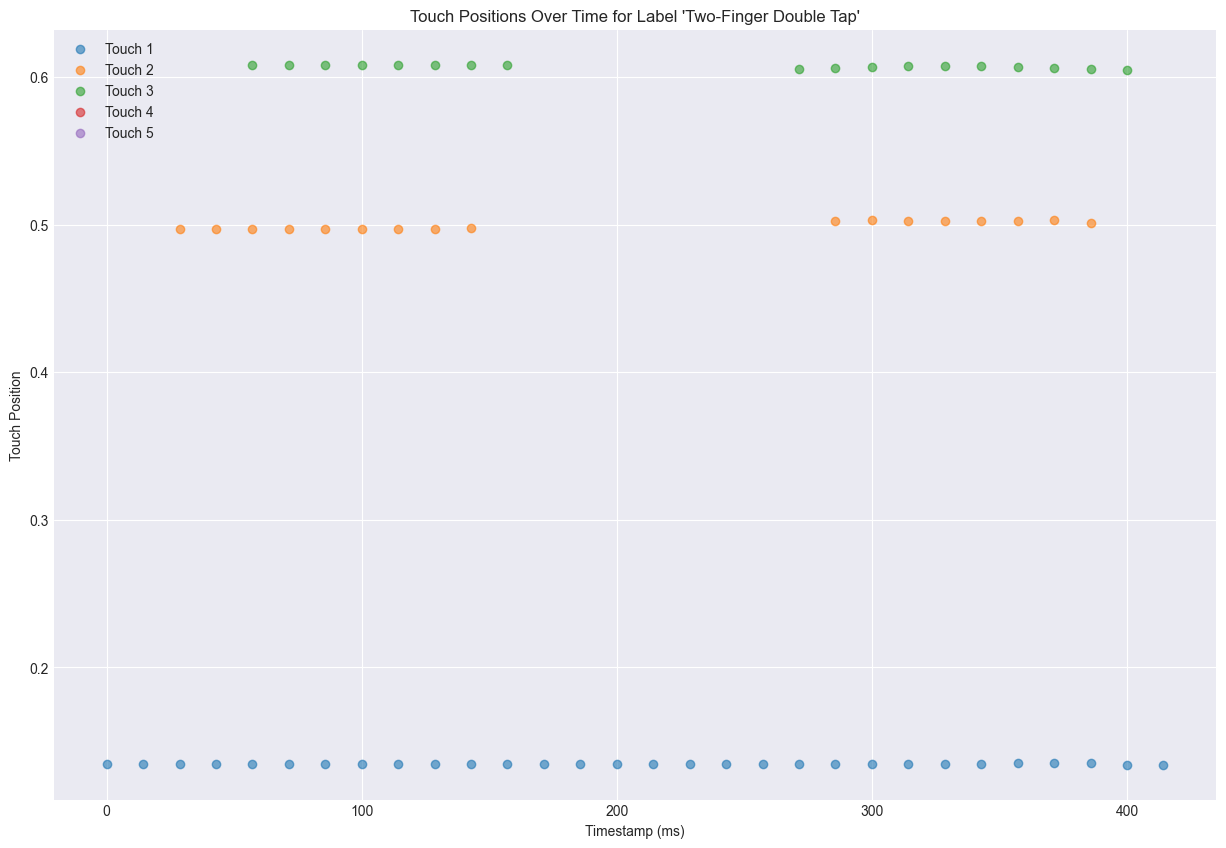

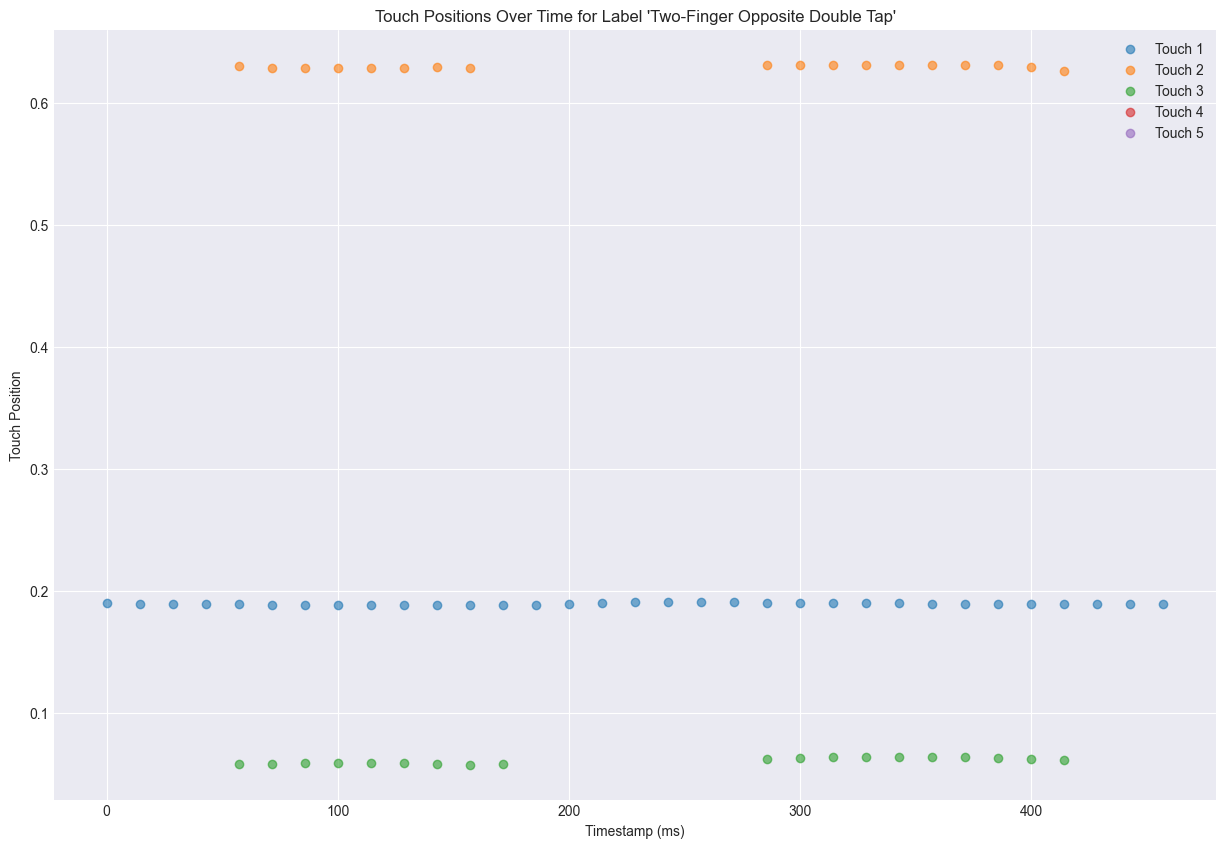

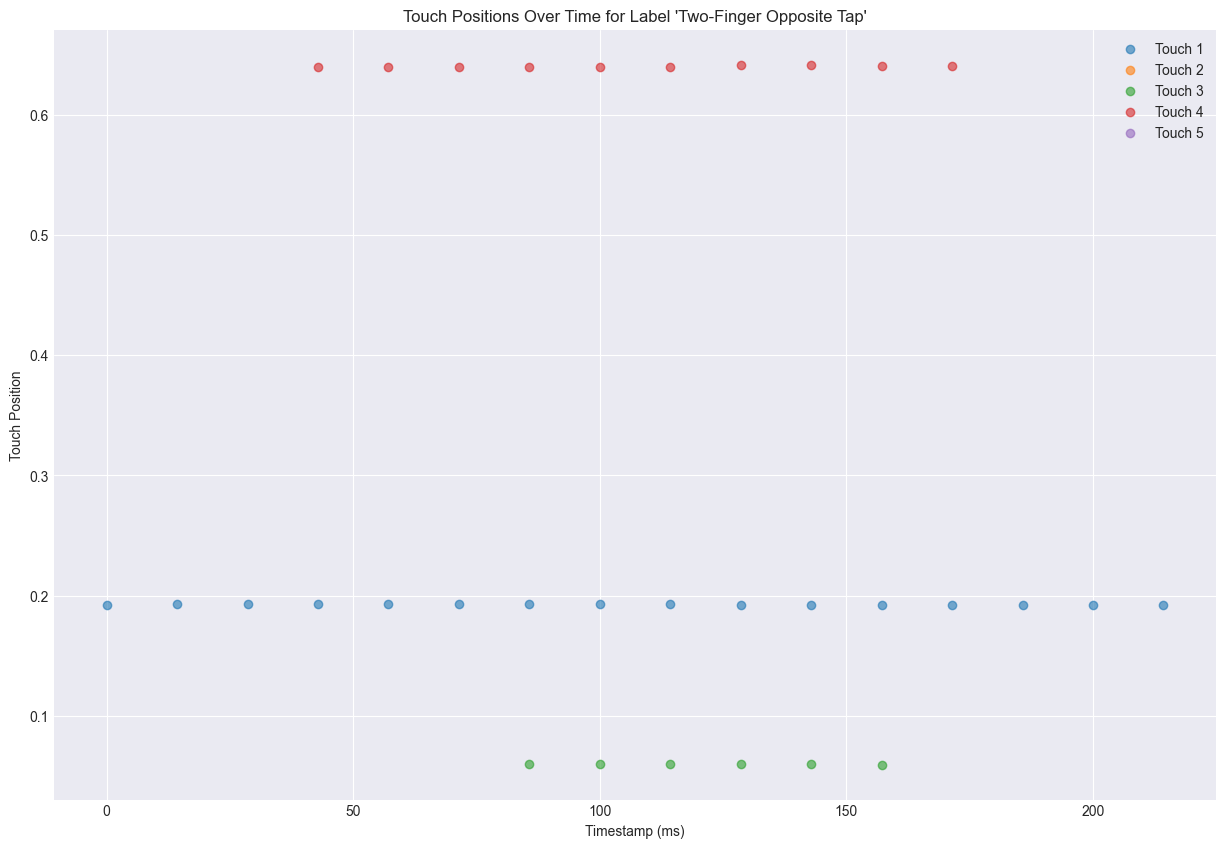

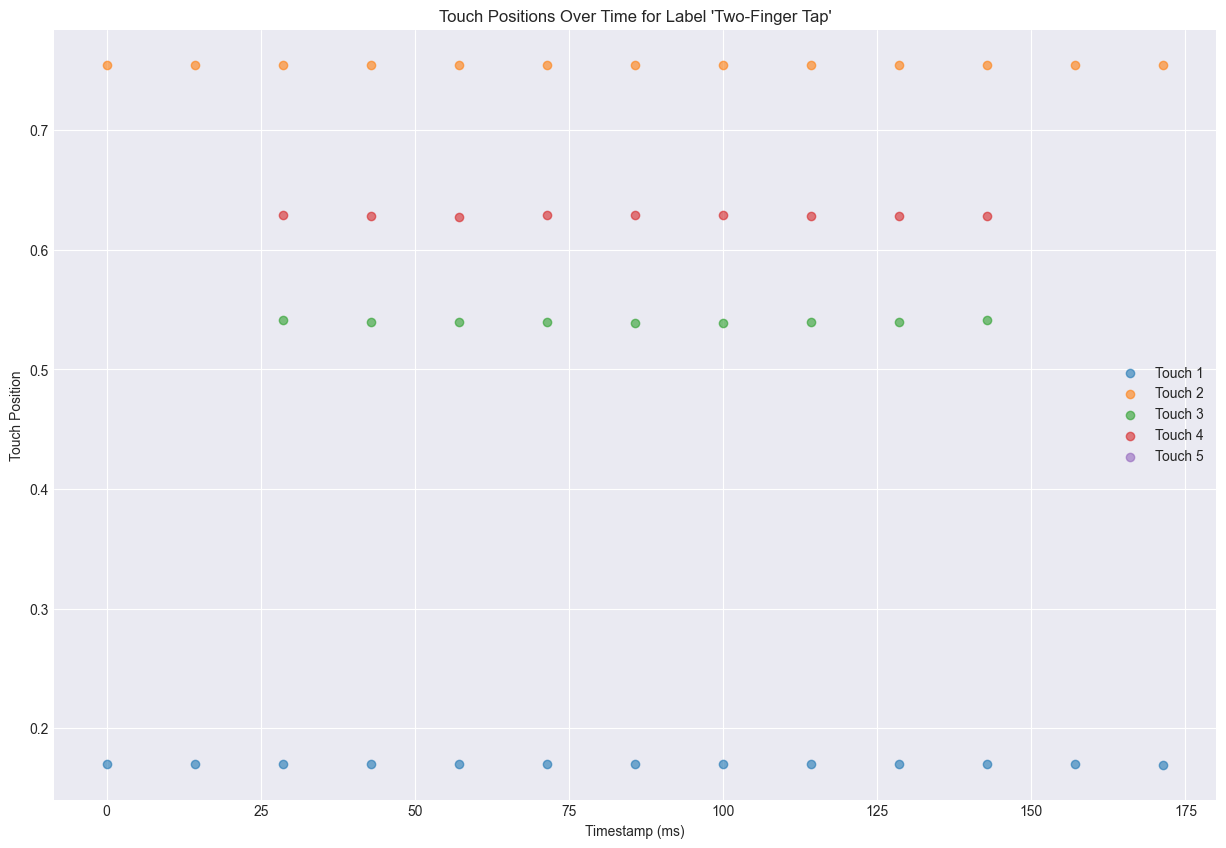

In [39]:
# For each LABEL_COLUMN in the test set, predict the first window and draw a graph with the finger positions over time
for label in le.classes_:
    # Find the first sequence in the test set with this label
    label_idx = np.where(le.classes_ == label)[0][0]
    seq_indices = np.where(np.argmax(y_test, axis=1) == label_idx)[0]
    if len(seq_indices) == 0:
        continue
    first_seq_idx = seq_indices[0]
    
    # Get the corresponding data
    seq_data = X_test[first_seq_idx]
    timestamps = np.arange(seq_data.shape[0]) * (1000 / SAMPLING_RATE_HZ)  # in ms

    plt.figure(figsize=(15, 10))
    for touch_num in range(1, 6):
        # Only print the fingers where the pressure > 0
        pressure_col_idx = feature_columns.index(f'touch_{touch_num}_pressure')
        active_mask = seq_data[:, pressure_col_idx] > 0
        plt.scatter(
            timestamps[active_mask], 
            seq_data[active_mask, feature_columns.index(f'touch_{touch_num}_position')], 
            label=f"Touch {touch_num}", 
            alpha=0.6
        )

    plt.xlabel("Timestamp (ms)")
    plt.ylabel("Touch Position")
    plt.title(f"Touch Positions Over Time for Label '{label}'")
    plt.legend()
    plt.show()

## Test with Szenarios

In [40]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    'Szenarien' AS gesture,
    'Szenarien' AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
WHERE is_gesture = 1 and marker_label != 'No Gesture'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,a0caf874-3fba-49a4-bd0e-36c370027f6b,002f4422-1f7b-4859-8f03-467e1f752000,335,2025-10-07 14:11:50,0,176.687363,0.395707,2063.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
1,b1971afb-c70b-45e2-970b-18512dd7beb4,002f4422-1f7b-4859-8f03-467e1f752000,336,2025-10-07 14:11:50,0,176.688904,0.394840,2067.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
2,7bbb27f4-3e45-467d-ba1e-a789024e1baf,002f4422-1f7b-4859-8f03-467e1f752000,337,2025-10-07 14:11:50,0,176.688126,0.394715,2065.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
3,86cfce39-cbc9-4917-86b6-fd2a80b1b3e3,002f4422-1f7b-4859-8f03-467e1f752000,338,2025-10-07 14:11:50,0,176.690048,0.394072,2079.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335
4,c0cc105f-ec8c-4dd0-b8cd-4d1b61a9350a,002f4422-1f7b-4859-8f03-467e1f752000,339,2025-10-07 14:11:50,0,176.691193,0.393592,2081.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Szenarien,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,1,Tap and Hold,2025-10-07 14:11:50-marker:Tap and Hold:start-335


In [41]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [42]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df_raw[col] = szenarien_df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df_raw['motor_angle'] = szenarien_df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [43]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [44]:
# Filter out all rows that dont have a marker_label that ends with "Tap"
szenarien_df = szenarien_df[szenarien_df["marker_label"].str.endswith("Tap")]
szenarien_df = szenarien_df.reset_index(drop=True)

Session Task ID: 319a52f3-2f36-4460-ba9d-a4346666683f


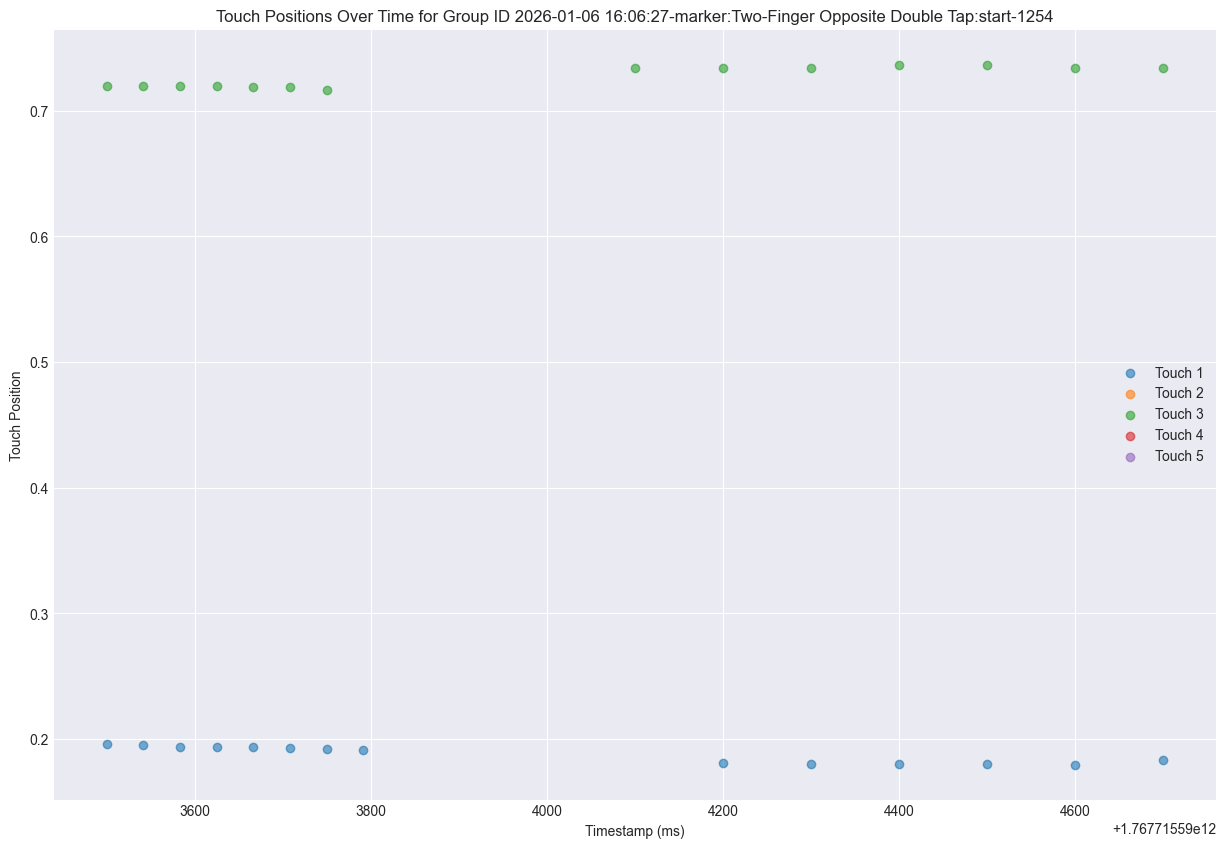

In [45]:
# Draw a graph of the first group_id in szenarien_df a scatter plot of touch positions over time
plt.figure(figsize=(15, 10))
first_group_id = szenarien_df["group_id"].unique()[14]
group_df = szenarien_df[szenarien_df["group_id"] == first_group_id]
# print the session_task_id
print(f"Session Task ID: {group_df['session_task_id'].iloc[0]}")
for touch_num in range(1, 6):
    plt.scatter(
        group_df["timestamp_ms"], 
        group_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Group ID {first_group_id}")
plt.legend()
plt.show()

In [46]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
group_id            0
dtype: int64

In [47]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
Two-Finger Tap                    553
Two-Finger Double Tap             516
Two-Finger Opposite Double Tap    486
Double Tap                        367
Two-Finger Opposite Tap           315
Single Tap                         22
Name: count, dtype: int64


In [48]:
# Print count of unique session_tasks
print(f"Unique session_task_ids in Szenarien data: {szenarien_df['session_task_id'].nunique()}")

Unique session_task_ids in Szenarien data: 20


In [49]:
# Make feature_df
szenarien_feature_df, szenarien_additional_columns = create_feature_df(szenarien_df)
szenarien_feature_columns = SENSOR_COLUMNS + szenarien_additional_columns

In [50]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)

for sid, sdf in szenarien_feature_df.groupby("session_task_id"):
    X_stream = sdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    streams[sid] = X_stream
    streams_labels[sid] = y_stream

In [51]:
# Print number of streams
print(f"Extracted {len(streams)} streams from Szenarien data.")

Extracted 20 streams from Szenarien data.


In [52]:
max_len = 25
step_size = 10
threshold = 0.05             # gesture confidence; tune this

print(f"Using max_len={max_len}, threshold={threshold} for online prediction.")
touch_indices = [2, 5, 8, 11, 14]  # position columns for touch_1 to touch_5

# For debug purposes draw a graph of the finger positions for each window
def predict_stream_online(X_stream):
    did_print = 0
    T, D = X_stream.shape
    preds = []
    pred_times = []

    # Create a figure with 5 rows (one for each window we plan to print)
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        window = X_stream[t_start:t_end]

        # plt.figure(figsize=(12, 8))    
        # # Draw all 5 fingers on THIS window's plot
        # for i, touch_num in enumerate(range(1, 6)):
        #     col_idx = touch_indices[i]
        #     x_vals = np.arange(t_start, t_end)
        #     y_vals = window[:, col_idx]
            
        #     plt.scatter(
        #         x_vals, 
        #         y_vals, 
        #         label=f"Touch {touch_num}", 
        #         alpha=0.6, 
        #         s=12
        #     )
        
        # get real label for this window (majority vote in the window)
        # real_labels_window = streams_labels[sid][t_start:t_end]

        # plt.xlabel("Time Step")
        # plt.ylabel("Touch Position")
        # plt.title(f"Window starting at index {t_start} - Real Label: {pd.Series(real_labels_window).mode()[0]}")
        # plt.legend(loc="upper right", markerscale=2)
        # plt.grid(True, alpha=0.3)
        # plt.tight_layout()
        # plt.show()

        # --- Model Prediction Logic ---
        window_batch = window[np.newaxis, ...]
        proba = model.predict(window_batch, verbose=0)[0]
        
        # print all probabilities for debug with label
        # for cls_idx, class_label in enumerate(le.classes_):
        #     print(f"  {class_label}: {proba[cls_idx]:.4f}")

        cls_idx = np.argmax(proba)
        confidence = proba[cls_idx]
        label = le.classes_[cls_idx] # if confidence >= threshold else "No Gesture"
        
        preds.append(label)
        pred_times.append(t_start)

        did_print += 1
        # if did_print >= 5:
        #     break

    return np.array(preds), np.array(pred_times)


Using max_len=25, threshold=0.05 for online prediction.


In [53]:
from sklearn.metrics import confusion_matrix, classification_report

all_true = []
all_pred = []

# print streams keys
did_it = 0
for sid, X_stream in streams.items():
    did_it += 1
    if did_it <= 3:
        continue
    y_stream = streams_labels[sid] 
    preds, pred_times = predict_stream_online(X_stream)

    # Use center index for each window
    centers = pred_times + max_len // 2

    for p_label, c in zip(preds, centers):
        if c >= len(y_stream):
            continue
        all_pred.append(p_label)
        all_true.append(y_stream[c] if y_stream[c] is not None else "No Gesture")

    # Print y_stream for those that are not none
    # print(f"True labels for stream {sid}:")
    # for i in range(len(y_stream)):
    #     if y_stream[i] is not None:
    #         print(f"  Index {i}: {y_stream[i]}")

    # if did_it >= 4:
    #     break


In [54]:
# Print unique all_true and all_pred labels
all_true = np.array(all_true)
all_pred = np.array(all_pred)
# Replace None with "No Gesture" in all_true
all_true = np.array([label if label is not None and label != 'No Gesture' else "No Gesture" for label in all_true])
unique_true_labels = np.unique(all_true)
unique_pred_labels = np.unique(all_pred)
print(f"Unique true labels: {unique_true_labels}")
print(f"Unique predicted labels: {unique_pred_labels}")

Unique true labels: ['Double Tap' 'Single Tap' 'Two-Finger Double Tap'
 'Two-Finger Opposite Double Tap' 'Two-Finger Opposite Tap'
 'Two-Finger Tap']
Unique predicted labels: ['Double Tap' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']


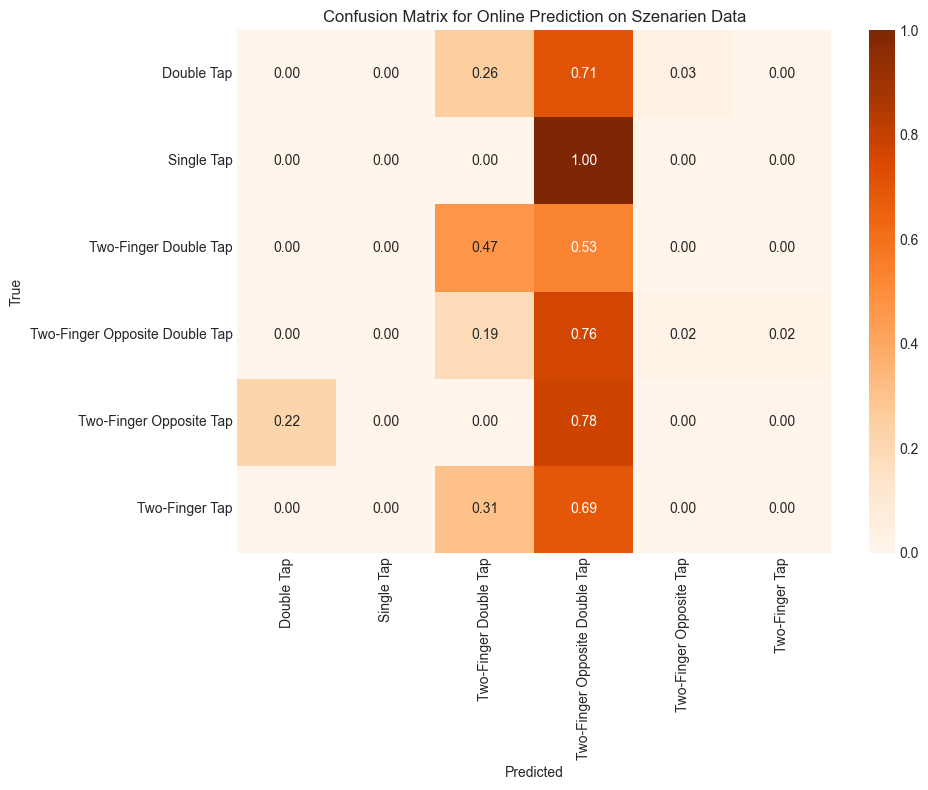

In [55]:
# Optionally restrict to known classes
# map string labels -> indices with same LabelEncoder if classes match
y_true_int = le.transform(all_true)           # if marker labels use same names
y_pred_int = le.transform(all_pred)

cm = confusion_matrix(y_true_int, y_pred_int)
# print(classification_report(y_true_int, y_pred_int, target_names=le.classes_))

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Oranges"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Online Prediction on Szenarien Data")
plt.tight_layout()
plt.show()


In [56]:
# Test with szenarios, but give a whole marker_label group at once to check if the classification would work with the correct windowing strategy

# Put all group_ids in windows
windows = []
window_lables = []
window_meta = []
for gid, gdf in szenarien_feature_df.groupby("group_id"):
    # ignore if the marker_label is "No Gesture" or None
    if gdf["marker_label"].iloc[0] is None or gdf["marker_label"].iloc[0] == "No Gesture":
        continue
    X_window = gdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    windows.append(X_window)
    window_lables.append(gdf["marker_label"].iloc[0])
    window_meta.append({
        "session_task_id": gdf["session_task_id"].iloc[0],
        "participant_id": gdf["participant_id"].iloc[0],
        "group_id": gid
    })

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 84 windows from Szenarien data for group_id prediction.


Window 0 - Session Task ID: ac15322e-3057-4cf5-8b28-16b1148a04a3, Participant ID: d3b39f0f-b799-4d69-b7a3-a663e5c7438f, Group ID: 2025-10-03 16:02:49-marker:Two-Finger Double Tap:start-2043
Window 0 Prediction Confidences:
  Two-Finger Double Tap: 0.56
  Two-Finger Opposite Double Tap: 0.26
  Two-Finger Tap: 0.11


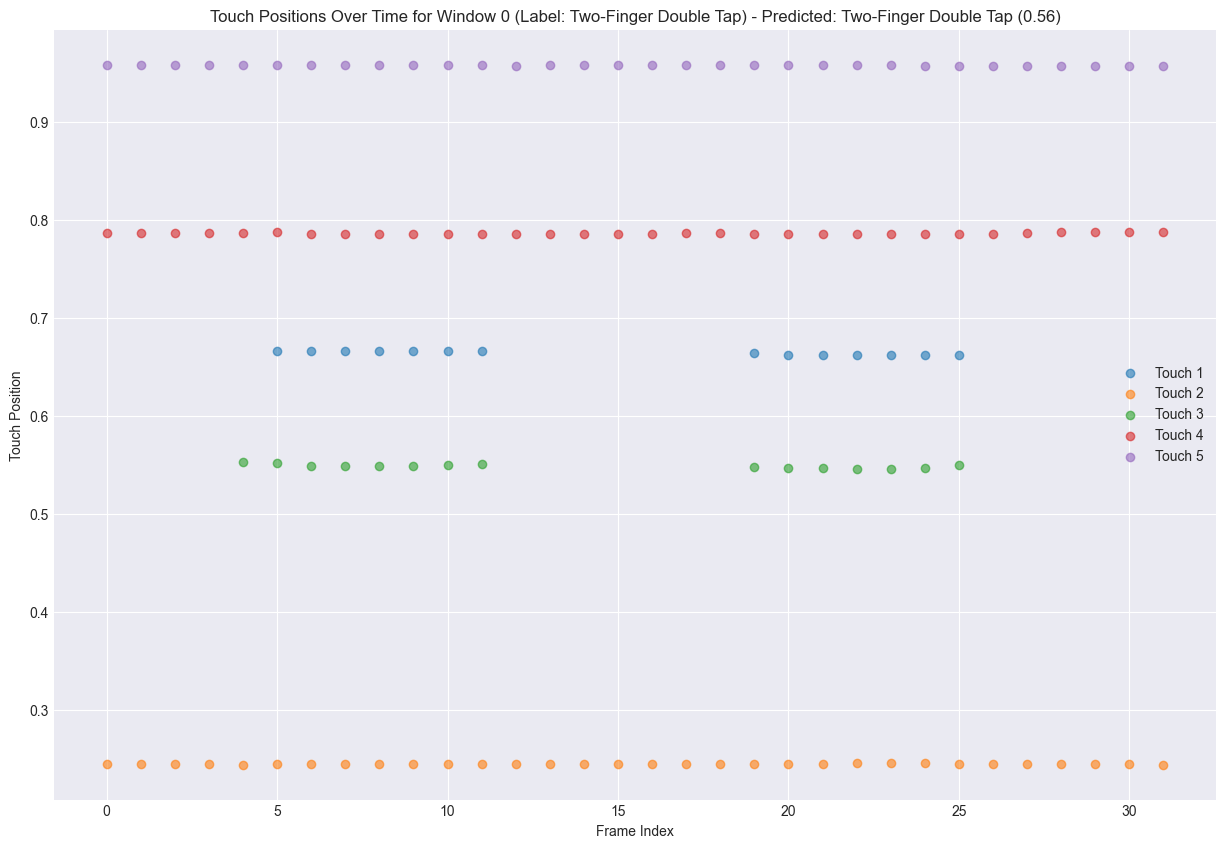

Window 1 - Session Task ID: ac15322e-3057-4cf5-8b28-16b1148a04a3, Participant ID: d3b39f0f-b799-4d69-b7a3-a663e5c7438f, Group ID: 2025-10-03 16:02:49-marker:Two-Finger Tap:start-1728
Window 1 Prediction Confidences:
  Double Tap: 0.13
  Single Tap: 0.10
  Two-Finger Double Tap: 0.43
  Two-Finger Opposite Double Tap: 0.10
  Two-Finger Tap: 0.22


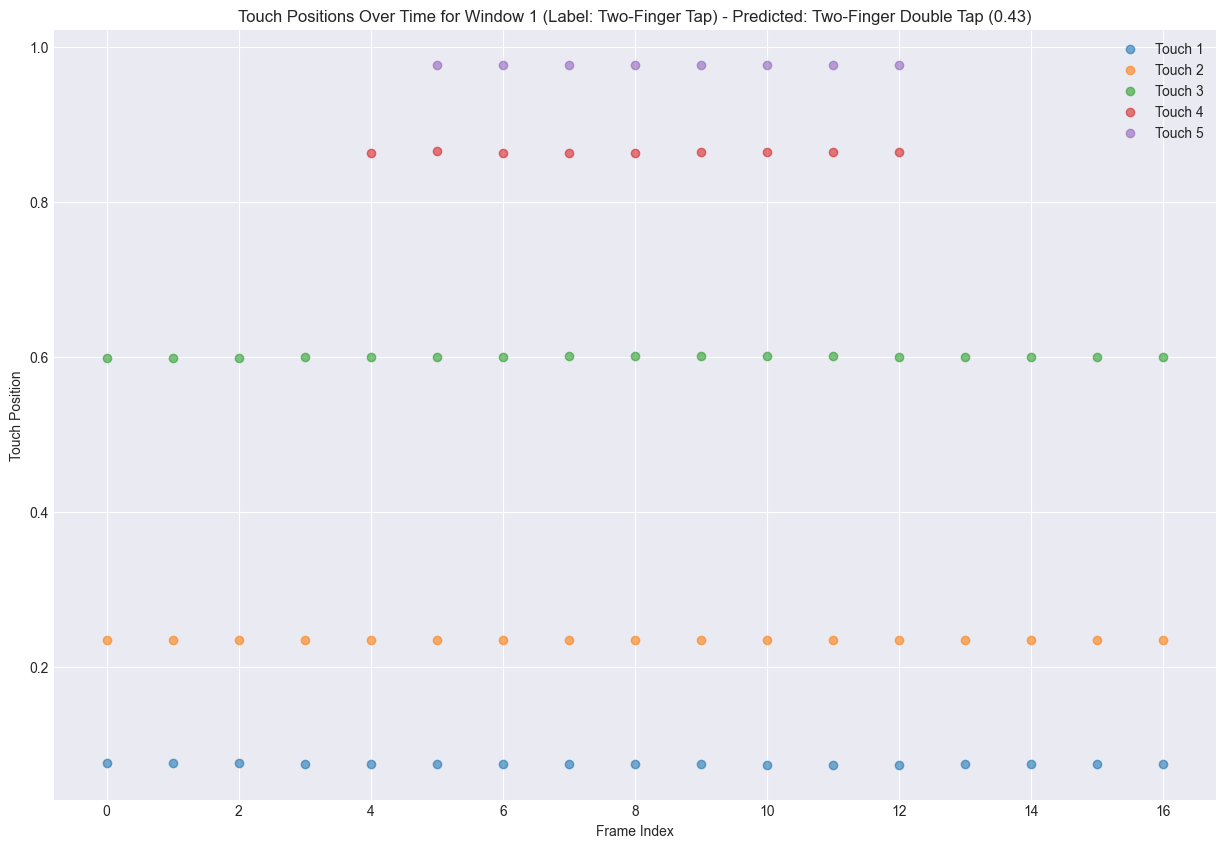

Window 2 - Session Task ID: ac15322e-3057-4cf5-8b28-16b1148a04a3, Participant ID: d3b39f0f-b799-4d69-b7a3-a663e5c7438f, Group ID: 2025-10-03 16:02:49-marker:Two-Finger Tap:start-1946
Window 2 Prediction Confidences:
  Two-Finger Double Tap: 0.58
  Two-Finger Opposite Double Tap: 0.21
  Two-Finger Tap: 0.13


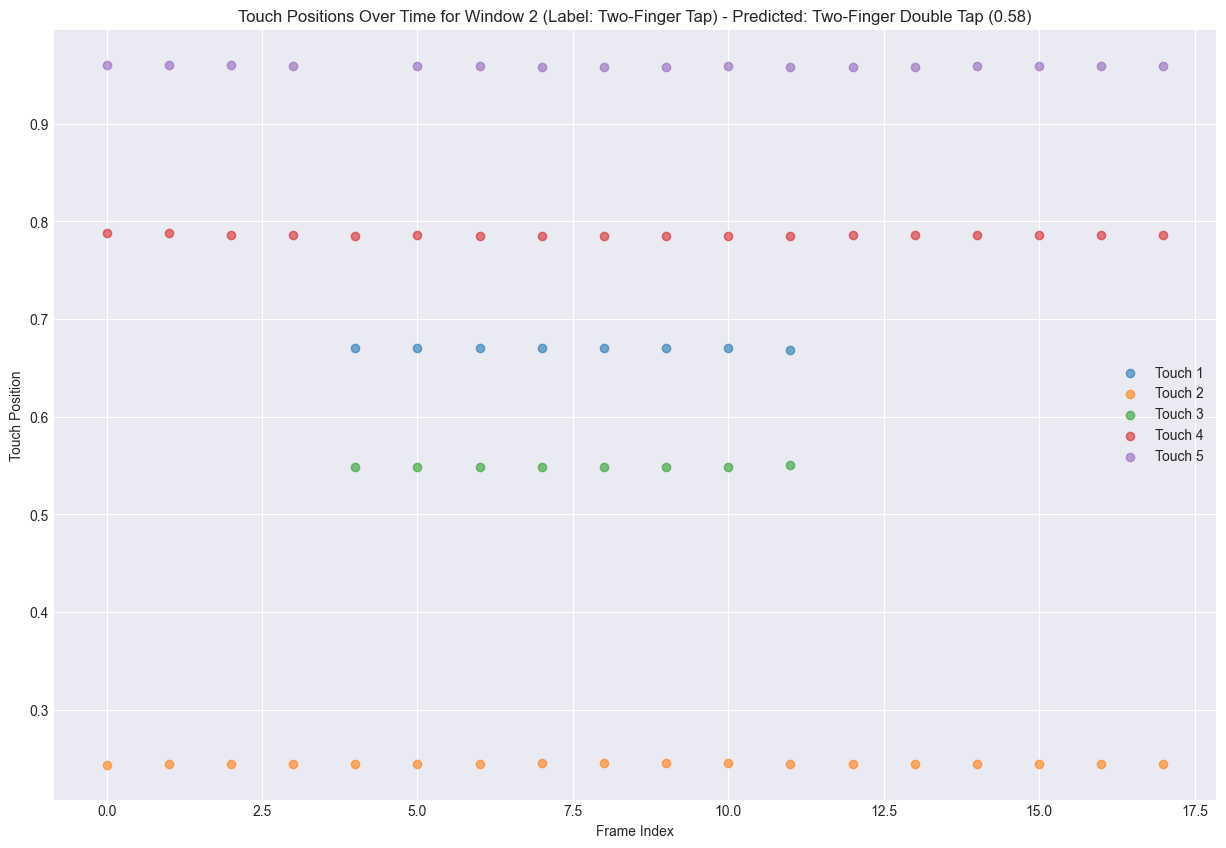

Window 3 - Session Task ID: ac15322e-3057-4cf5-8b28-16b1148a04a3, Participant ID: d3b39f0f-b799-4d69-b7a3-a663e5c7438f, Group ID: 2025-10-03 16:03:11-marker:Two-Finger Double Tap:start-3745
Window 3 Prediction Confidences:
  Double Tap: 0.09
  Single Tap: 0.06
  Two-Finger Double Tap: 0.56
  Two-Finger Opposite Double Tap: 0.13
  Two-Finger Tap: 0.14


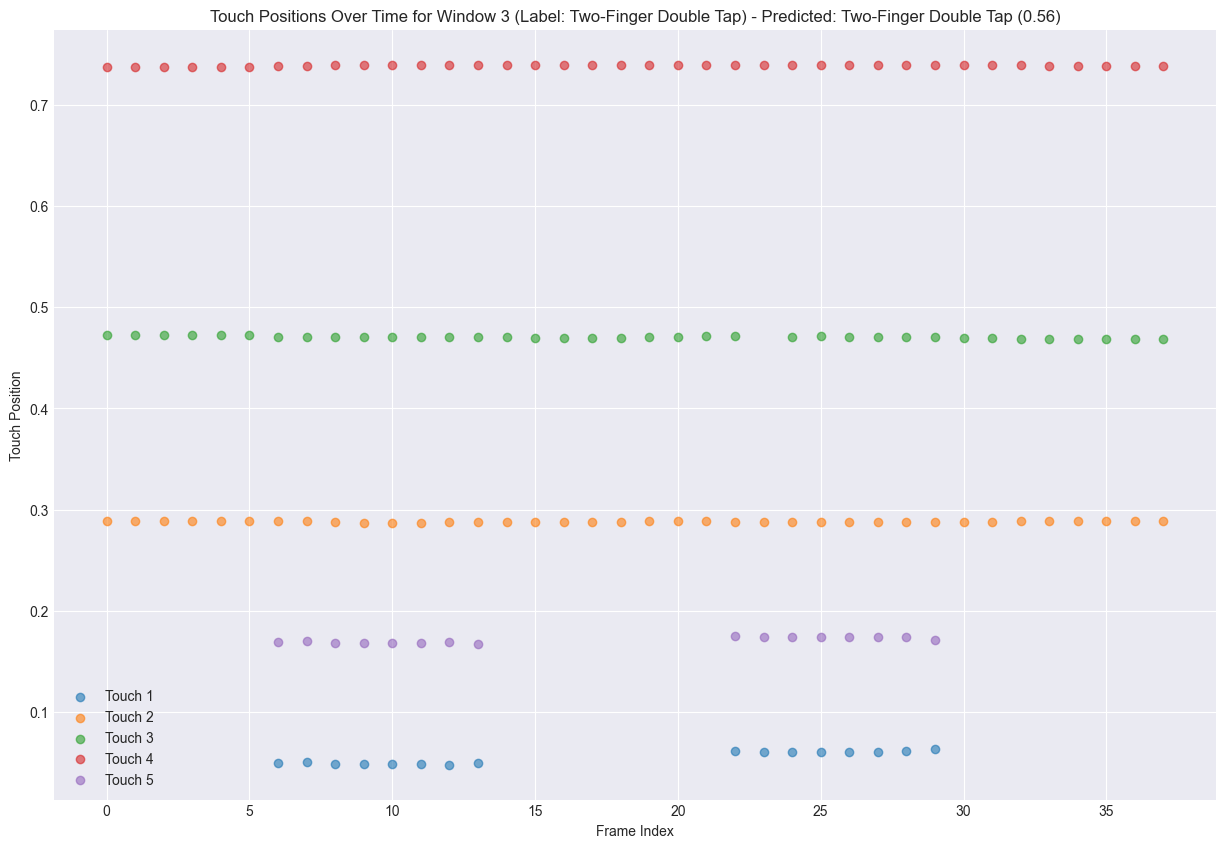

Window 4 - Session Task ID: 0542a515-ad14-49ec-84d7-c3b4e8b6ffe2, Participant ID: d3b39f0f-b799-4d69-b7a3-a663e5c7438f, Group ID: 2025-10-03 16:06:39-marker:Two-Finger Opposite Tap:start-1988
Window 4 Prediction Confidences:
  Two-Finger Opposite Double Tap: 0.96


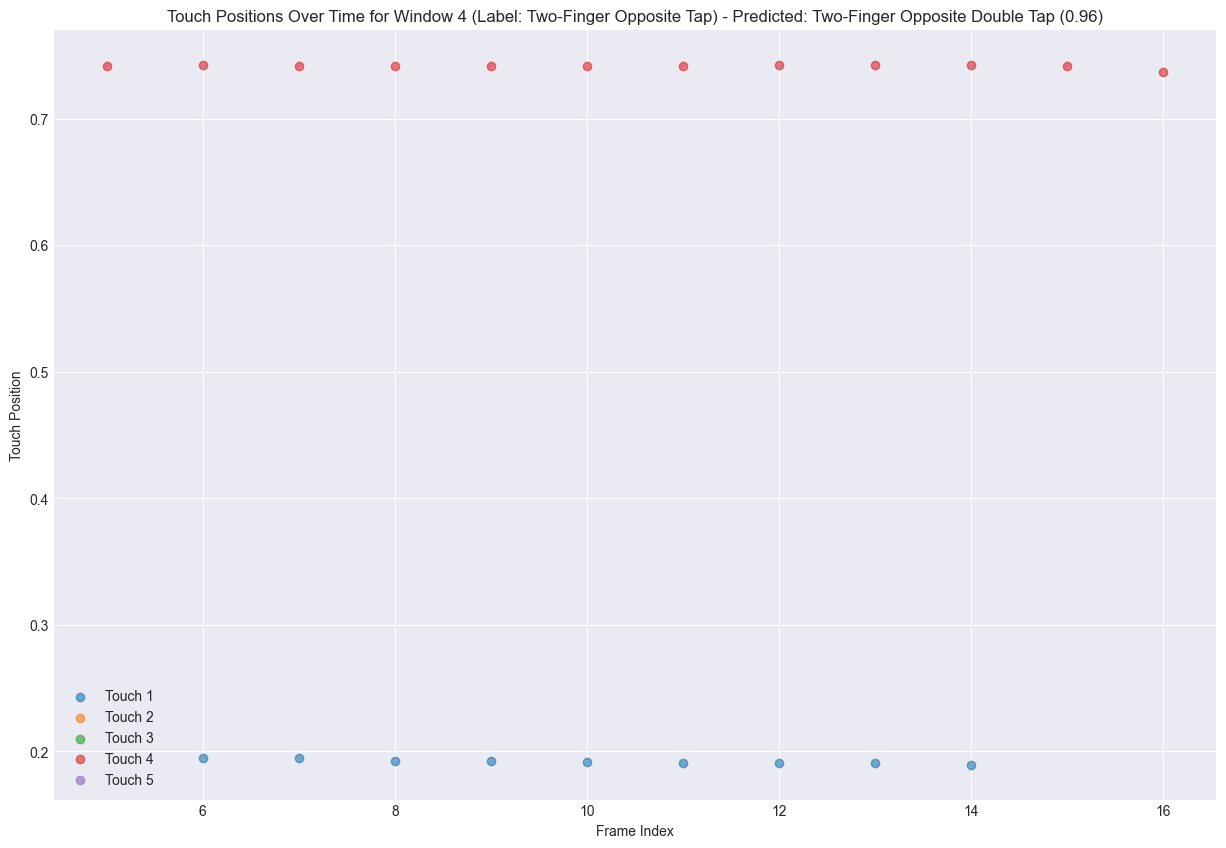

In [57]:
# Draw graphs of the first 5 windows and their finger positions
for w_idx in range(min(5, len(windows))):
    plt.figure(figsize=(15, 10))
    window = windows[w_idx]

    # Print session_task_id for window
    meta = window_meta[w_idx]
    print(f"Window {w_idx} - Session Task ID: {meta['session_task_id']}, Participant ID: {meta['participant_id']}, Group ID: {meta['group_id']}")    
    
    prediction = model.predict(window[np.newaxis, ...], verbose=0)[0]
    cls_idx = np.argmax(prediction)
    conf = prediction[cls_idx]
    predicted_label = le.classes_[cls_idx]

    # Print all prediction confidences that are above 0.05
    print(f"Window {w_idx} Prediction Confidences:")
    for cls_i, class_label in enumerate(le.classes_):
        prob = prediction[cls_i]
        if prob >= 0.05:
            print(f"  {class_label}: {prob:.2f}")

    label = window_lables[w_idx]
    for touch_num in range(1, 6):
        # Only get indices that have non-zero positions
        pressure_col_idx = touch_indices[touch_num - 1] + 1  # pressure column index
        touch_indices_cleaned = np.where(window[:, pressure_col_idx] > 0)[0]
        plt.scatter(
            touch_indices_cleaned, 
            window[touch_indices_cleaned, touch_indices[touch_num - 1]], 
            label=f"Touch {touch_num}", 
            alpha=0.6
        )
    plt.xlabel("Frame Index")
    plt.ylabel("Touch Position")
    plt.title(f"Touch Positions Over Time for Window {w_idx} (Label: {label}) - Predicted: {predicted_label} ({conf:.2f})")
    plt.legend()
    plt.show()

In [58]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=6, max=73
Window label counts:
  Two-Finger Tap: 29
  Two-Finger Double Tap: 15
  Two-Finger Opposite Double Tap: 14
  Two-Finger Opposite Tap: 13
  Double Tap: 11
  Single Tap: 2


In [59]:
# Predict each window
all_window_true = []
all_window_pred = []

for X_window, true_label in zip(windows, window_lables):
    T, D = X_window.shape
    if T < max_len:
        # Pad if too short
        X_padded = np.pad(
            X_window,
            ((0, max_len - T), (0, 0)),
            mode="constant",
            constant_values=-1.0
        )
    else:
        # Truncate if too long
        X_padded = X_window[:max_len, :]

    X_batch = X_padded[np.newaxis, ...]  # (1, max_len, D)
    proba = model.predict(X_batch, verbose=0)[0]
    
    cls_idx = np.argmax(proba)
    conf = proba[cls_idx]
    pred_label = le.classes_[cls_idx] if conf >= threshold else "No Gesture"

    all_window_true.append(true_label)
    all_window_pred.append(pred_label)
# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
unique_window_true_labels = np.unique(all_window_true)
unique_window_pred_labels = np.unique(all_window_pred)
print(f"Unique true window labels: {unique_window_true_labels}")
print(f"Unique predicted window labels: {unique_window_pred_labels}")

Unique true window labels: ['Double Tap' 'Single Tap' 'Two-Finger Double Tap'
 'Two-Finger Opposite Double Tap' 'Two-Finger Opposite Tap'
 'Two-Finger Tap']
Unique predicted window labels: ['Two-Finger Double Tap' 'Two-Finger Opposite Double Tap']


                                precision    recall  f1-score   support

                    Double Tap       0.00      0.00      0.00        11
                    Single Tap       0.00      0.00      0.00         2
         Two-Finger Double Tap       0.27      0.40      0.32        15
Two-Finger Opposite Double Tap       0.16      0.71      0.26        14
       Two-Finger Opposite Tap       0.00      0.00      0.00        13
                Two-Finger Tap       0.00      0.00      0.00        29

                      accuracy                           0.19        84
                     macro avg       0.07      0.19      0.10        84
                  weighted avg       0.08      0.19      0.10        84



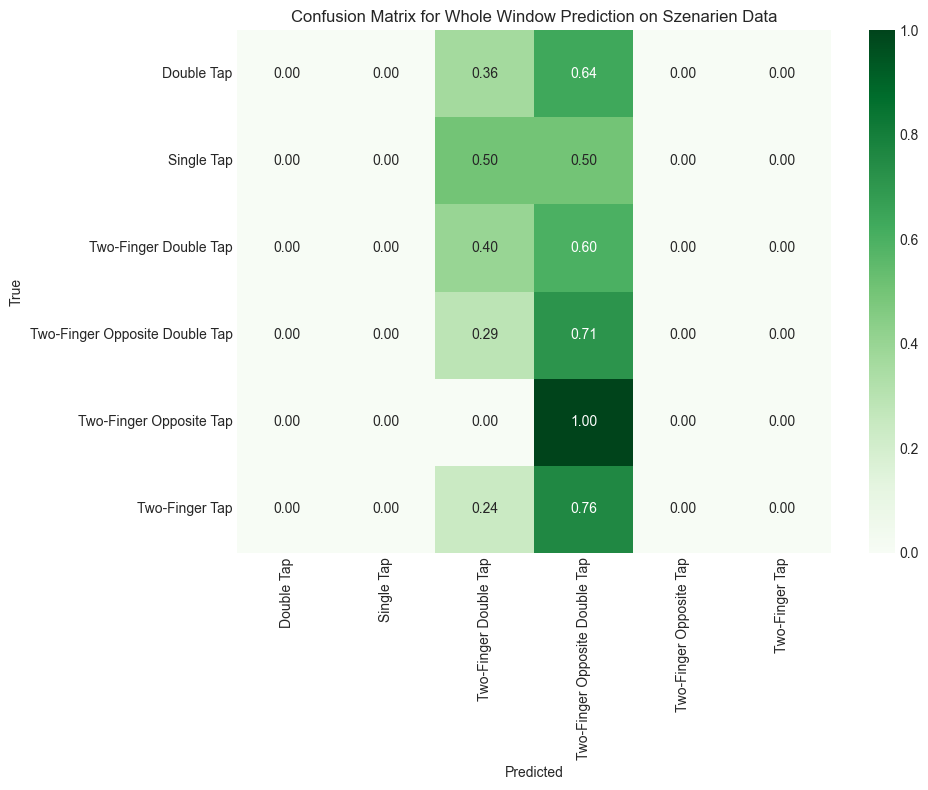

In [60]:
# Print confusion matrix and classification report for window predictions
y_window_true_int = le.transform(all_window_true)           # if marker labels use same names
y_window_pred_int = le.transform(all_window_pred)
cm_window = confusion_matrix(y_window_true_int, y_window_pred_int)
print(classification_report(y_window_true_int, y_window_pred_int, target_names=le.classes_))
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Whole Window Prediction on Szenarien Data")
plt.tight_layout()
plt.show()

In [61]:
# TODO Try out only relative data and remove the absolute data completely
# TODO Add something like the centroid and distances between everything to the feature set
# TODO Try out LSTM with windows and the window features